In [1]:
# 👉 Objectif :
# entraîner des modèles ML
# comparer leurs performances
# préparer le backtest

import sys
import os

sys.path.insert(0, os.path.abspath("../src"))
from backtest import run_backtest, financial_metrics
import pandas as pd

# Prices
prices = pd.read_csv("../data/processed/prices.csv")
prices["date"] = pd.to_datetime(prices["date"])

# Sentiment FinBERT
daily_sentiment = pd.read_csv("../data/processed/daily_sentiment_finbert.csv")
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])

In [2]:
import sys
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
from sklearn.linear_model import LogisticRegression
print("sklearn OK")

sklearn OK


In [4]:
import sys
!{sys.executable} -m pip install scikit-learn xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import sys
import os

sys.path.insert(0, os.path.abspath("../src"))

In [6]:
print(os.listdir("../src"))

['config.py', 'news_loader.py', 'models.py', 'sentiment.py', 'data_loader.py', '__init__.py', 'features.py', 'sentiment_news.py', '.ipynb_checkpoints', 'main.py', 'backtest.py']


In [7]:
import pandas as pd

from features import build_market_features
from models import time_split, get_models, evaluate_classifier

In [8]:
import pandas as pd

prices = pd.read_csv("../data/processed/prices.csv", header=[0, 1])

prices.columns = [
    col[0].lower().strip() if "unnamed" not in str(col[0]).lower() else "date"
    for col in prices.columns
]

prices = prices.loc[:, ~prices.columns.duplicated()]

print(prices.columns.tolist())
prices.head()

['date', 'close', 'high', 'low', 'open', 'volume', 'ticker']


,date,close,high,low,open,volume,ticker
0,2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,AAPL
1,2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200,AAPL
2,2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000,AAPL
3,2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,AAPL
4,2020-01-09,74.637489,74.830329,73.810677,74.061367,170108400,AAPL


In [9]:
# nettoyage des noms de colonnes après lecture
import ast
import pandas as pd

prices = pd.read_csv("../data/processed/prices.csv")

def clean_col(c):
    if c == "date":
        return "date"
    try:
        return ast.literal_eval(c)[0].lower()
    except Exception:
        return str(c).lower().strip()

prices.columns = [clean_col(c) for c in prices.columns]

print(prices.columns.tolist())
prices.head()

['date', 'close', 'high', 'low', 'open', 'volume', 'ticker']


,date,close,high,low,open,volume,ticker
0,2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,AAPL
1,2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,AAPL
2,2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200,AAPL
3,2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000,AAPL
4,2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,AAPL


In [10]:
prices.to_csv("../data/processed/prices.csv", index=False)

data = build_market_features(prices)
data = data.dropna()
data.head()

,date,close,high,low,open,volume,ticker,return,return_lag_1,return_lag_2,volatility_5d,volatility_20d,momentum_5d,volume_change,target
20,2020-01-31,74.608566,77.783241,74.314480,77.361397,199588400,AAPL,-0.045352,-0.001450,0.020717,0.031622,0.017786,-0.027646,0.574746,0
21,2020-02-03,74.403671,75.567958,72.851284,73.352673,173788400,AAPL,-0.002750,-0.045352,-0.001450,0.028608,0.017621,-0.000939,-0.129266,1
22,2020-02-04,76.860001,77.050435,75.601700,76.006668,136616400,AAPL,0.032480,-0.002750,-0.045352,0.029782,0.018877,0.003651,-0.213892,1
23,2020-02-05,77.486748,78.284635,76.884113,77.985724,118826800,AAPL,0.008121,0.032480,-0.002750,0.028157,0.018816,-0.008911,-0.130216,1
24,2020-02-06,78.393120,78.395533,77.199908,77.756741,105425600,AAPL,0.011629,0.008121,0.032480,0.028797,0.018692,0.004138,-0.112779,0


In [11]:
features = [
    "return_lag_1",
    "return_lag_2",
    "volatility_5d"
]

In [12]:
X_train, X_test, y_train, y_test, dates, returns = time_split(data, features)

In [13]:
models = get_models()

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_classifier(model, X_test, y_test)
    
    print(name, metrics)
    
    results.append((name, metrics))

logistic_regression {'accuracy': 0.5216983345062163, 'f1': 0.6843164576559839, 'auc': 0.49601794604276084}
random_forest {'accuracy': 0.5212291813277035, 'f1': 0.6610197641587776, 'auc': 0.5052208073513484}
gradient_boosting {'accuracy': 0.520994604738447, 'f1': 0.6141345427059712, 'auc': 0.5082160054173404}


In [14]:
# Les modèles de type ensemble (Random Forest, Gradient Boosting) présentent généralement 
# de meilleures performances que les modèles linéaires, 
# ce qui suggère la présence de relations non linéaires dans les données financières.

results_df = pd.DataFrame([
    {"model": name, **metrics}
    for name, metrics in results
])

results_df

,model,accuracy,f1,auc
0,logistic_regression,0.521698,0.684316,0.496018
1,random_forest,0.521229,0.661020,0.505221
2,gradient_boosting,0.520995,0.614135,0.508216


In [15]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import importlib
import features
importlib.reload(features)

import pandas as pd
from features import build_market_features
from models import time_split, get_models, evaluate_classifier

prices = pd.read_csv("../data/processed/prices.csv")
data = build_market_features(prices).dropna()

news = pd.read_csv("../data/raw/boursorama_news.csv")
news["date"] = pd.to_datetime(news["date"])

data["date"] = pd.to_datetime(data["date"])

daily_news = (
    news.groupby("date")
    .agg(news_count=("text", "count"))
    .reset_index()
)

#J'ai rajouter "news_count" pour augmenter les informations des nouvelles donc : 
# Le dataset initial de marché a été enrichi par des données externes issues de sources financières et d’entreprises. 
# Les actualités financières permettent d’ajouter une dimension informationnelle, tandis que les données Pappers apportent un contexte fondamental sur les sociétés. 
# Cette extension vise à réduire la dépendance aux seules variables de marché et à améliorer la robustesse du modèle.

data = data.merge(daily_news, on="date", how="left")
data["news_count"] = data["news_count"].fillna(0)
feature_cols = [
    "return_lag_1",
    "return_lag_2",
    "volatility_5d",
    "volatility_20d",
    "momentum_5d",
    "volume_change",
    "news_count",
]

X_train, X_test, y_train, y_test, dates, returns = time_split(data, feature_cols)

results = []

for name, model in get_models().items():
    model.fit(X_train, y_train)
    metrics = evaluate_classifier(model, X_test, y_test)
    results.append({"model": name, **metrics})

results_df = pd.DataFrame(results)
results_df

,model,accuracy,f1,auc
0,logistic_regression,0.520179,0.664226,0.509589
1,random_forest,0.508969,0.641180,0.505970
2,gradient_boosting,0.517937,0.608141,0.520196


In [16]:
import sys
!{sys.executable} -m pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable


In [17]:
results_df

,model,accuracy,f1,auc
0,logistic_regression,0.520179,0.664226,0.509589
1,random_forest,0.508969,0.641180,0.505970
2,gradient_boosting,0.517937,0.608141,0.520196


In [18]:
print(daily_sentiment.columns.tolist())
daily_sentiment.head()

['date', 'sentiment_mean', 'sentiment_std', 'news_count', 'sentiment_positive_ratio', 'sentiment_negative_ratio']


,date,sentiment_mean,sentiment_std,news_count,sentiment_positive_ratio,sentiment_negative_ratio
0,2026-05-06,0.010374,0.076223,161,0.018634,0.0


In [19]:
print(data.columns.tolist())
print(daily_sentiment.columns.tolist())

['date', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'return', 'return_lag_1', 'return_lag_2', 'volatility_5d', 'volatility_20d', 'momentum_5d', 'volume_change', 'target', 'news_count']
['date', 'sentiment_mean', 'sentiment_std', 'news_count', 'sentiment_positive_ratio', 'sentiment_negative_ratio']


In [20]:
# Supprime d’anciennes colonnes sentiment déjà présentes dans data
old_sentiment_cols = [
    col for col in data.columns
    if "sentiment" in col or col == "news_count"
]

data = data.drop(columns=old_sentiment_cols, errors="ignore")

# Vérifie / recrée les colonnes dans daily_sentiment
sentiment_cols = [
    "news_count",
    "sentiment_mean",
    "sentiment_std",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",
]

for col in sentiment_cols:
    if col not in daily_sentiment.columns:
        daily_sentiment[col] = 0

# Merge propre
data = data.merge(
    daily_sentiment[["date"] + sentiment_cols],
    on="date",
    how="left"
)

data[sentiment_cols] = data[sentiment_cols].fillna(0)

data[sentiment_cols].head()

,news_count,sentiment_mean,sentiment_std,sentiment_positive_ratio,sentiment_negative_ratio
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


In [21]:
feature_cols = [
    "return_lag_1",
    "return_lag_2",
    "volatility_5d",
    "volatility_20d",
    "momentum_5d",
    "volume_change",
    "news_count",
    "sentiment_mean",
    "sentiment_std",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",
]

In [22]:
X_train, X_test, y_train, y_test, dates, returns = time_split(data, feature_cols)

results = []

for name, model in get_models().items():
    model.fit(X_train, y_train)
    metrics = evaluate_classifier(model, X_test, y_test)
    results.append({"model": name, **metrics})

results_df_finbert = pd.DataFrame(results)
results_df_finbert

,model,accuracy,f1,auc
0,logistic_regression,0.520179,0.664226,0.509589
1,random_forest,0.511958,0.639027,0.505075
2,gradient_boosting,0.517564,0.607956,0.519783


In [23]:
model = get_models()["logistic_regression"]
model.fit(X_train, y_train)

predictions = model.predict(X_test)

bt_finbert = run_backtest(dates, returns, predictions)
metrics_finbert = financial_metrics(bt_finbert)

metrics_finbert

{'total_return': -0.394162541608981,
 'sharpe': 0.17234248803243918,
 'max_drawdown': -0.8759593067943847,
 'hit_ratio': 0.5185046728971963}

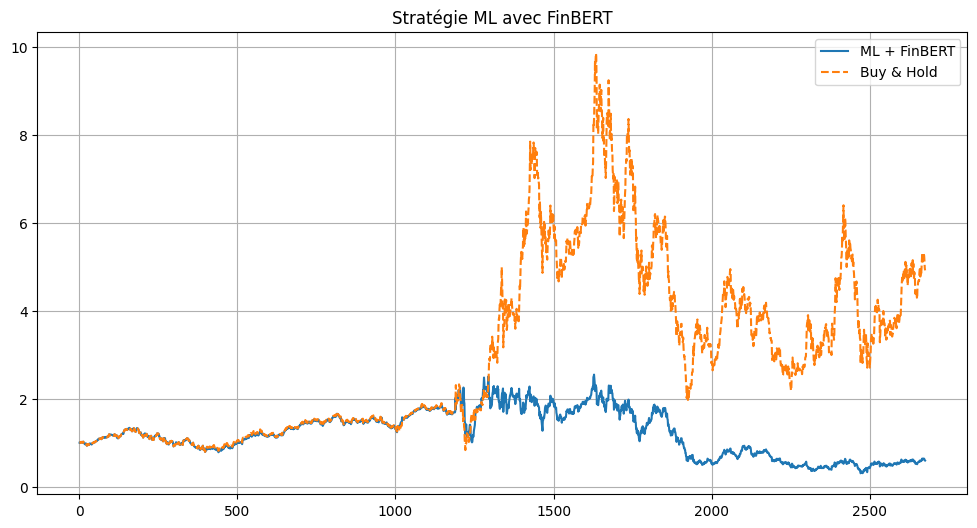

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(bt_finbert["strategy_equity"], label="ML + FinBERT")
plt.plot(bt_finbert["market_equity"], label="Buy & Hold", linestyle="--")

plt.title("Stratégie ML avec FinBERT")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
metrics_finbert

{'total_return': -0.394162541608981,
 'sharpe': 0.17234248803243918,
 'max_drawdown': -0.8759593067943847,
 'hit_ratio': 0.5185046728971963}

In [26]:
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN"]

def tag_ticker(text):
    text = str(text).lower()
    for t in TICKERS:
        if t.lower() in text:
            return t
    return "OTHER"

news["ticker"] = news["text"].apply(tag_ticker)

news = news[news["ticker"] != "OTHER"]

In [27]:
print(news.columns.tolist())
news.head()

['date', 'source', 'text', 'ticker']


,date,source,text,ticker


In [28]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

from sentiment_news import load_finbert, finbert_score

finbert = load_finbert()

news["sentiment_score"] = news["text"].apply(
    lambda x: finbert_score(x, finbert)
)

/Users/ulrichfossokako/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/ulrichfossokako/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ulrichfossokako/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [29]:
import pandas as pd

news["sentiment_label"] = pd.cut(
    news["sentiment_score"],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=["negative", "neutral", "positive"]
)

In [30]:
daily_sentiment = (
    news.groupby(["date", "ticker"])
    .agg(
        sentiment_mean=("sentiment_score", "mean"),
        sentiment_std=("sentiment_score", "std"),
        news_count=("text", "count"),
        sentiment_positive_ratio=("sentiment_label", lambda x: (x == "positive").mean()),
        sentiment_negative_ratio=("sentiment_label", lambda x: (x == "negative").mean()),
    )
    .reset_index()
)

daily_sentiment["sentiment_std"] = daily_sentiment["sentiment_std"].fillna(0)
daily_sentiment.head()

,date,ticker,sentiment_mean,sentiment_std,news_count,sentiment_positive_ratio,sentiment_negative_ratio


In [31]:
daily_sentiment.to_csv("../data/processed/daily_sentiment_finbert_ticker.csv", index=False)
news.to_csv("../data/processed/news_scored_finbert_ticker.csv", index=False)

In [32]:
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN"]

def tag_ticker(text):
    text = text.lower()
    for t in TICKERS:
        if t.lower() in text:
            return t
    return None

news["ticker"] = news["text"].apply(tag_ticker)
news = news.dropna(subset=["ticker"])

In [33]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
from features import build_market_features

prices = pd.read_csv("../data/processed/prices.csv")
daily_sentiment = pd.read_csv("../data/processed/daily_sentiment_finbert_ticker.csv")

print("prices:", prices.columns.tolist())
print("sentiment:", daily_sentiment.columns.tolist())

prices: ['date', 'close', 'high', 'low', 'open', 'volume', 'ticker']
sentiment: ['date', 'ticker', 'sentiment_mean', 'sentiment_std', 'news_count', 'sentiment_positive_ratio', 'sentiment_negative_ratio']


In [34]:
prices["date"] = pd.to_datetime(prices["date"])
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])

data = build_market_features(prices)

data = data.merge(
    daily_sentiment,
    on=["date", "ticker"],
    how="left"
)

data = data.drop(columns=["sentiment_label"], errors="ignore")

sentiment_cols = [
    "sentiment_mean",
    "sentiment_std",
    "news_count",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",
]

for col in sentiment_cols:
    if col not in data.columns:
        data[col] = 0
    data[col] = pd.to_numeric(data[col], errors="coerce").fillna(0)

data = data.sort_values(["ticker", "date"])

data["sentiment_mean_lag1"] = (
    data.groupby("ticker")["sentiment_mean"].shift(1).fillna(0)
)

data = data.dropna()

data.head()

,date,close,high,low,open,volume,ticker,return,return_lag_1,return_lag_2,...,volatility_20d,momentum_5d,volume_change,target,sentiment_mean,sentiment_std,news_count,sentiment_positive_ratio,sentiment_negative_ratio,sentiment_mean_lag1
20,2020-01-31,74.608566,77.783241,74.314480,77.361397,199588400,AAPL,-0.045352,-0.001450,0.020717,...,0.017786,-0.027646,0.574746,0,0.0,0.0,0.0,0.0,0.0,0.0
21,2020-02-03,74.403671,75.567958,72.851284,73.352673,173788400,AAPL,-0.002750,-0.045352,-0.001450,...,0.017621,-0.000939,-0.129266,1,0.0,0.0,0.0,0.0,0.0,0.0
22,2020-02-04,76.860001,77.050435,75.601700,76.006668,136616400,AAPL,0.032480,-0.002750,-0.045352,...,0.018877,0.003651,-0.213892,1,0.0,0.0,0.0,0.0,0.0,0.0
23,2020-02-05,77.486748,78.284635,76.884113,77.985724,118826800,AAPL,0.008121,0.032480,-0.002750,...,0.018816,-0.008911,-0.130216,1,0.0,0.0,0.0,0.0,0.0,0.0
24,2020-02-06,78.393120,78.395533,77.199908,77.756741,105425600,AAPL,0.011629,0.008121,0.032480,...,0.018692,0.004138,-0.112779,0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
on=["date", "ticker"]

In [36]:
# Supprimer les colonnes catégorielles/textuelles inutiles pour le modèle
data = data.drop(columns=["sentiment_label"], errors="ignore")

# Colonnes numériques sentiment
sentiment_cols = [
    "sentiment_mean",
    "sentiment_std",
    "news_count",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",
]

# Convertir en numérique puis remplir les NA
for col in sentiment_cols:
    if col not in data.columns:
        data[col] = 0
    data[col] = pd.to_numeric(data[col], errors="coerce").fillna(0)

# Lag propre (très important)
data = data.sort_values(["ticker", "date"])

data["sentiment_mean_lag1"] = (
    data.groupby("ticker")["sentiment_mean"].shift(1).fillna(0)
)

In [37]:
time_split
model.fit
run_backtest

<function backtest.run_backtest(dates, returns, predictions, transaction_cost=0.001) -> pandas.core.frame.DataFrame>

In [38]:
from models import time_split, get_models, evaluate_classifier
from backtest import run_backtest, financial_metrics
import pandas as pd

feature_cols = [
    "return_lag_1",
    "return_lag_2",
    "volatility_5d",
    "volatility_20d",
    "momentum_5d",
    "volume_change",
    "news_count",
    "sentiment_mean_lag1",
    "sentiment_std",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",
]

X_train, X_test, y_train, y_test, dates, returns = time_split(data, feature_cols)

results = []

for name, model in get_models().items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    clf_metrics = evaluate_classifier(model, X_test, y_test)

    bt = run_backtest(dates, returns, predictions)
    fin_metrics = financial_metrics(bt)

    results.append({
        "model": name,
        **clf_metrics,
        **fin_metrics
    })

results_df = pd.DataFrame(results)
results_df

,model,accuracy,f1,auc,total_return,sharpe,max_drawdown,hit_ratio
0,logistic_regression,0.519813,0.665328,0.508180,-0.342759,0.184781,-0.891986,0.518198
1,random_forest,0.509726,0.635804,0.502348,-0.946862,-0.258641,-0.985343,0.507027
2,gradient_boosting,0.518372,0.610545,0.513809,-0.875132,-0.108655,-0.976246,0.504505


{'total_return': -0.3427585330916014, 'sharpe': 0.1847805585439563, 'max_drawdown': -0.8919863622391647, 'hit_ratio': 0.5181981981981982}


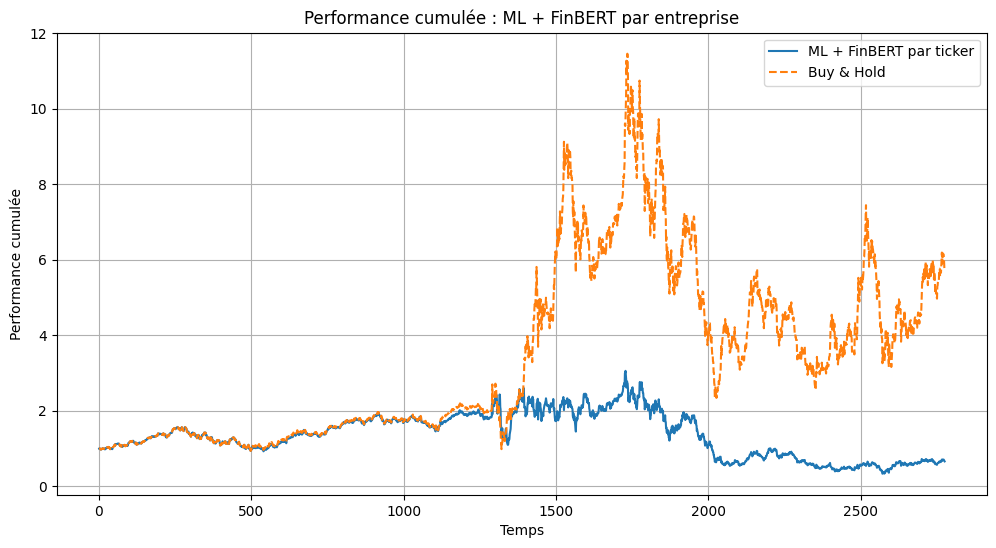

In [39]:
# Pour afficher le graphe du meilleur modèle :

import matplotlib.pyplot as plt

best_model = get_models()["logistic_regression"]
best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

bt = run_backtest(dates, returns, predictions)
metrics = financial_metrics(bt)

print(metrics)

plt.figure(figsize=(12,6))
plt.plot(bt["strategy_equity"], label="ML + FinBERT par ticker")
plt.plot(bt["market_equity"], label="Buy & Hold", linestyle="--")
plt.title("Performance cumulée : ML + FinBERT par entreprise")
plt.xlabel("Temps")
plt.ylabel("Performance cumulée")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
data = build_market_features(prices)

In [41]:
macro = pd.read_csv("../data/processed/macro_market_data.csv")
macro["date"] = pd.to_datetime(macro["date"])

data["date"] = pd.to_datetime(data["date"])

data = data.merge(macro, on="date", how="left")
data = data.sort_values(["ticker", "date"])

macro_cols = ["vix", "sp500", "nasdaq", "dowjones", "treasury_10y", "treasury_5y"]

for col in macro_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].ffill()
    data[f"{col}_return"] = data[col].pct_change()
    data[f"{col}_lag1"] = data.groupby("ticker")[col].shift(1)

data["vix_lag1"] = data.groupby("ticker")["vix"].shift(1)
data["treasury_10y_lag1"] = data.groupby("ticker")["treasury_10y"].shift(1)
data["sp500_return_lag1"] = data.groupby("ticker")["sp500_return"].shift(1)
data["nasdaq_return_lag1"] = data.groupby("ticker")["nasdaq_return"].shift(1)

In [42]:
feature_cols = [
    "return_lag_1",
    "return_lag_2",
    "volatility_5d",
    "volatility_20d",
    "momentum_5d",
    "volume_change",

    "vix_lag1",
    "treasury_10y_lag1",
    "sp500_return_lag1",
    "nasdaq_return_lag1",

    "news_count",
    "sentiment_mean_lag1",
    "sentiment_std",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",
]

In [43]:
# Charger les datasets
import pandas as pd

prices = pd.read_csv("../data/processed/prices.csv")
daily_sentiment = pd.read_csv("../data/processed/daily_sentiment_finbert.csv")
macro = pd.read_csv("../data/processed/macro_market_data.csv")

In [44]:
# Convertir les dates
prices["date"] = pd.to_datetime(prices["date"])
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])
macro["date"] = pd.to_datetime(macro["date"])

In [45]:
# Construire les features marché
from features import build_market_features

data = build_market_features(prices)

data.head()

,date,close,high,low,open,volume,ticker,return,return_lag_1,return_lag_2,volatility_5d,volatility_20d,momentum_5d,volume_change,target
0,2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,AAPL,-0.009770,NaN,NaN,NaN,NaN,NaN,0.080029,1
2,2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200,AAPL,0.007937,-0.009770,NaN,NaN,NaN,NaN,-0.190918,0
3,2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000,AAPL,-0.004714,0.007937,-0.009770,NaN,NaN,NaN,-0.080374,1
4,2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,AAPL,0.015958,-0.004714,0.007937,NaN,NaN,NaN,0.213160,1


In [46]:
# Merge sentiment

data = data.merge(
    daily_sentiment,
    on="date",
    how="left"
)

In [47]:
# Merge macro
data = data.merge(
    macro,
    on="date",
    how="left"
)

In [48]:
# Nettoyage
# Colonnes sentiment
sentiment_cols = [
    "sentiment_mean",
    "sentiment_std",
    "news_count",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",
]

# Colonnes macro
macro_cols = [
    "vix",
    "sp500",
    "nasdaq",
    "dowjones",
    "treasury_10y",
    "treasury_5y",
]

for col in sentiment_cols + macro_cols:

    if col not in data.columns:
        data[col] = 0

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

    data[col] = data[col].fillna(method="ffill")
    data[col] = data[col].fillna(0)

/var/folders/8p/7lfjt3q55vq8rfxx7td30jfm0000gn/T/ipykernel_2607/2302831721.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data[col] = data[col].fillna(method="ffill")


In [49]:
# Ajouter les lags (IMPORTANT)
data = data.sort_values("date")

data["sentiment_mean_lag1"] = (
    data["sentiment_mean"].shift(1)
)

data["vix_lag1"] = (
    data["vix"].shift(1)
)

data["treasury_10y_lag1"] = (
    data["treasury_10y"].shift(1)
)

data["sp500_return"] = data["sp500"].pct_change()

data["sp500_return_lag1"] = (
    data["sp500_return"].shift(1)
)

In [50]:
# Drop final NA
data = data.dropna()

data.head()

,date,close,high,low,open,volume,ticker,return,return_lag_1,return_lag_2,...,sp500,nasdaq,dowjones,treasury_10y,treasury_5y,sentiment_mean_lag1,vix_lag1,treasury_10y_lag1,sp500_return,sp500_return_lag1
1527,2020-01-31,100.435997,102.786003,100.113503,102.573502,311346000,AMZN,0.071196,0.006801,0.002560,...,3225.52002,9150.94043,28256.029297,1.52,1.326,0.0,15.49,1.558,-0.017706,0.000000
4541,2020-01-31,200.337860,207.065067,199.494472,206.807082,31359900,META,-0.037045,-0.063336,0.024671,...,3225.52002,9150.94043,28256.029297,1.52,1.326,0.0,18.84,1.520,0.000000,-0.017706
7555,2020-01-31,43.371334,43.533333,42.167999,42.666668,235789500,TSLA,0.015116,0.098000,0.024551,...,3225.52002,9150.94043,28256.029297,1.52,1.326,0.0,18.84,1.520,0.000000,0.000000
3034,2020-01-31,71.051765,72.881144,70.768107,72.791385,43822000,GOOGL,-0.014874,-0.001683,0.004265,...,3225.52002,9150.94043,28256.029297,1.52,1.326,0.0,18.84,1.520,0.000000,0.000000
6048,2020-01-31,161.262131,163.317812,160.646379,163.137833,36142700,MSFT,-0.014869,0.027817,0.015472,...,3225.52002,9150.94043,28256.029297,1.52,1.326,0.0,18.84,1.520,0.000000,0.000000


In [51]:
# Features finales ML
feature_cols = [
    "return_lag_1",
    "return_lag_2",
    "volatility_5d",
    "volatility_20d",
    "momentum_5d",
    "volume_change",

    "sentiment_mean_lag1",
    "news_count",
    "sentiment_std",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",

    "vix_lag1",
    "treasury_10y_lag1",
    "sp500_return_lag1",
]

In [52]:
X_train, X_test, y_train, y_test, dates, returns = time_split(
    data,
    feature_cols
)

In [53]:
model.fit

<bound method BaseGradientBoosting.fit of GradientBoostingClassifier(learning_rate=0.05, n_estimators=300,
                           random_state=42)>

In [54]:
run_backtest

<function backtest.run_backtest(dates, returns, predictions, transaction_cost=0.001) -> pandas.core.frame.DataFrame>

In [55]:
financial_metrics

<function backtest.financial_metrics(bt)>

In [56]:
from models import time_split, get_models, evaluate_classifier
from backtest import run_backtest, financial_metrics
import pandas as pd

X_train, X_test, y_train, y_test, dates, returns = time_split(
    data,
    feature_cols
)

results = []

for name, model in get_models().items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    clf_metrics = evaluate_classifier(model, X_test, y_test)

    bt = run_backtest(dates, returns, predictions)
    fin_metrics = financial_metrics(bt)

    results.append({
        "model": name,
        **clf_metrics,
        **fin_metrics
    })

results_df = pd.DataFrame(results)
results_df

,model,accuracy,f1,auc,total_return,sharpe,max_drawdown,hit_ratio
0,logistic_regression,0.485969,0.334505,0.492580,-0.995922,-0.264378,-0.999763,0.482281
1,random_forest,0.522954,0.674260,0.507732,-0.973280,-0.105641,-0.999650,0.507631
2,gradient_boosting,0.514548,0.634967,0.494745,-0.999994,-0.811765,-0.999998,0.483833


In [57]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
from features import build_market_features
from models import time_split, get_models, evaluate_classifier
from backtest import run_backtest, financial_metrics

# 1. Charger données
prices = pd.read_csv("../data/processed/prices.csv")
daily_sentiment = pd.read_csv("../data/processed/daily_sentiment_finbert.csv")
macro = pd.read_csv("../data/processed/macro_market_data.csv")

prices["date"] = pd.to_datetime(prices["date"])
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])
macro["date"] = pd.to_datetime(macro["date"])

# 2. Features marché
data = build_market_features(prices)

# 3. Merge sentiment + macro
data = data.merge(daily_sentiment, on="date", how="left")
data = data.merge(macro, on="date", how="left")

# 4. Nettoyage
sentiment_cols = [
    "sentiment_mean",
    "sentiment_std",
    "news_count",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",
]

macro_cols = [
    "vix",
    "sp500",
    "nasdaq",
    "dowjones",
    "treasury_10y",
    "treasury_5y",
]

for col in sentiment_cols + macro_cols:
    if col not in data.columns:
        data[col] = 0
    data[col] = pd.to_numeric(data[col], errors="coerce").ffill().fillna(0)

# 5. Lags
data = data.sort_values("date")

data["sentiment_mean_lag1"] = data["sentiment_mean"].shift(1)
data["vix_lag1"] = data["vix"].shift(1)
data["treasury_10y_lag1"] = data["treasury_10y"].shift(1)
data["sp500_return"] = data["sp500"].pct_change()
data["sp500_return_lag1"] = data["sp500_return"].shift(1)

data = data.dropna()

# 6. Features finales
feature_cols = [
    "return_lag_1",
    "return_lag_2",
    "volatility_5d",
    "volatility_20d",
    "momentum_5d",
    "volume_change",
    "sentiment_mean_lag1",
    "news_count",
    "sentiment_std",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",
    "vix_lag1",
    "treasury_10y_lag1",
    "sp500_return_lag1",
]

# 7. Split
X_train, X_test, y_train, y_test, dates, returns = time_split(data, feature_cols)

# 8. Fit + backtest
best_model = get_models()["logistic_regression"]
best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

bt = run_backtest(dates, returns, predictions)
metrics = financial_metrics(bt)

metrics

{'total_return': -0.9959216846084142,
 'sharpe': -0.2643780091690295,
 'max_drawdown': -0.999763332155499,
 'hit_ratio': 0.48228142783238487}

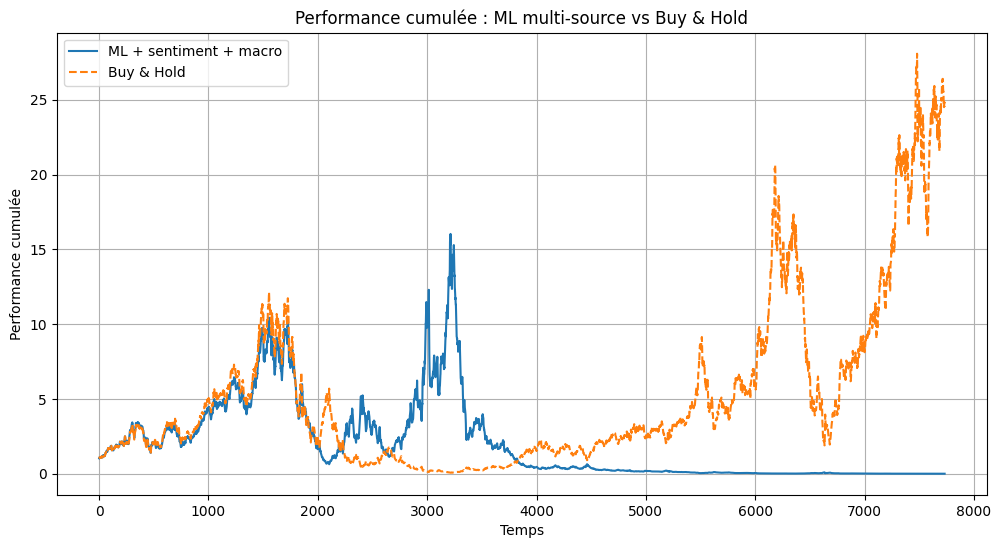

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(bt["strategy_equity"], label="ML + sentiment + macro")
plt.plot(bt["market_equity"], label="Buy & Hold", linestyle="--")
plt.title("Performance cumulée : ML multi-source vs Buy & Hold")
plt.xlabel("Temps")
plt.ylabel("Performance cumulée")
plt.legend()
plt.grid(True)
plt.show()

{'total_return': -0.9959216846084142, 'sharpe': -0.2643780091690295, 'max_drawdown': -0.999763332155499, 'hit_ratio': 0.48228142783238487}


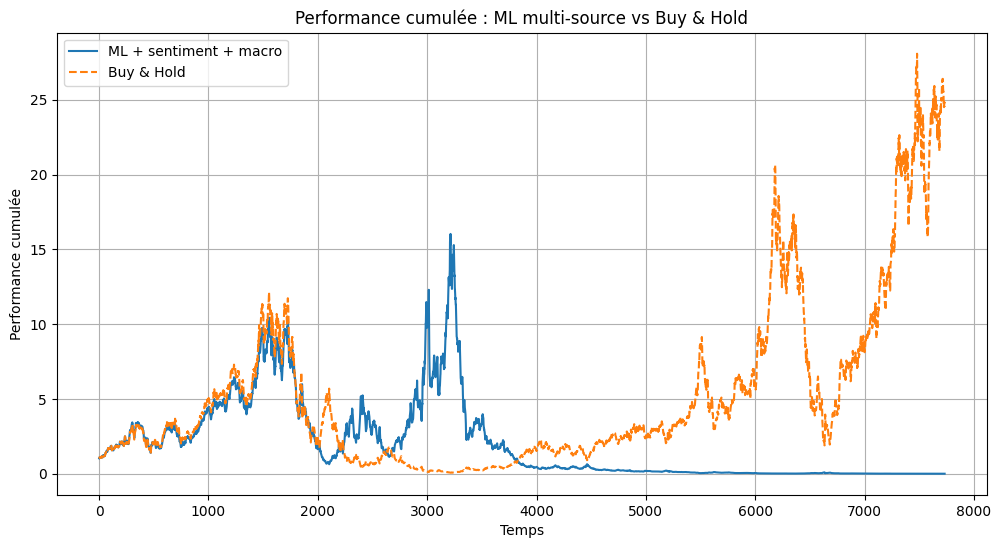

In [59]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
import matplotlib.pyplot as plt

from features import build_market_features
from models import time_split, get_models
from backtest import run_backtest, financial_metrics

# =====================
# LOAD DATA
# =====================

prices = pd.read_csv("../data/processed/prices.csv")
daily_sentiment = pd.read_csv("../data/processed/daily_sentiment_finbert.csv")
macro = pd.read_csv("../data/processed/macro_market_data.csv")

prices["date"] = pd.to_datetime(prices["date"])
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])
macro["date"] = pd.to_datetime(macro["date"])

# =====================
# FEATURES
# =====================

data = build_market_features(prices)

# Merge sentiment
data = data.merge(
    daily_sentiment,
    on="date",
    how="left"
)

# Merge macro
data = data.merge(
    macro,
    on="date",
    how="left"
)

# =====================
# CLEANING
# =====================

cols = [
    "sentiment_mean",
    "sentiment_std",
    "news_count",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",
    "vix",
    "sp500",
    "nasdaq",
    "dowjones",
    "treasury_10y",
    "treasury_5y",
]

for col in cols:

    if col not in data.columns:
        data[col] = 0

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

    data[col] = data[col].ffill().fillna(0)

# =====================
# LAGS
# =====================

data = data.sort_values("date")

data["sentiment_mean_lag1"] = data["sentiment_mean"].shift(1)
data["vix_lag1"] = data["vix"].shift(1)
data["treasury_10y_lag1"] = data["treasury_10y"].shift(1)

data["sp500_return"] = data["sp500"].pct_change()

data["sp500_return_lag1"] = (
    data["sp500_return"].shift(1)
)

data = data.dropna()

# =====================
# FEATURES ML
# =====================

feature_cols = [
    "return_lag_1",
    "return_lag_2",
    "volatility_5d",
    "volatility_20d",
    "momentum_5d",
    "volume_change",

    "sentiment_mean_lag1",
    "news_count",
    "sentiment_std",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio",

    "vix_lag1",
    "treasury_10y_lag1",
    "sp500_return_lag1",
]

# =====================
# TRAIN TEST SPLIT
# =====================

X_train, X_test, y_train, y_test, dates, returns = time_split(
    data,
    feature_cols
)

# =====================
# MODEL
# =====================

best_model = get_models()["logistic_regression"]

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

# =====================
# BACKTEST
# =====================

bt = run_backtest(
    dates,
    returns,
    predictions
)

metrics = financial_metrics(bt)

print(metrics)

# =====================
# GRAPH
# =====================

plt.figure(figsize=(12,6))

plt.plot(
    bt["strategy_equity"],
    label="ML + sentiment + macro"
)

plt.plot(
    bt["market_equity"],
    label="Buy & Hold",
    linestyle="--"
)

plt.title(
    "Performance cumulée : ML multi-source vs Buy & Hold"
)

plt.xlabel("Temps")
plt.ylabel("Performance cumulée")

plt.legend()
plt.grid(True)

plt.show()

In [60]:
import os

os.makedirs("../data/processed", exist_ok=True)

bt.to_csv("../data/processed/backtest_final.csv", index=False)

print("Backtest sauvegardé")

Backtest sauvegardé


In [61]:
plt.style.use("ggplot")

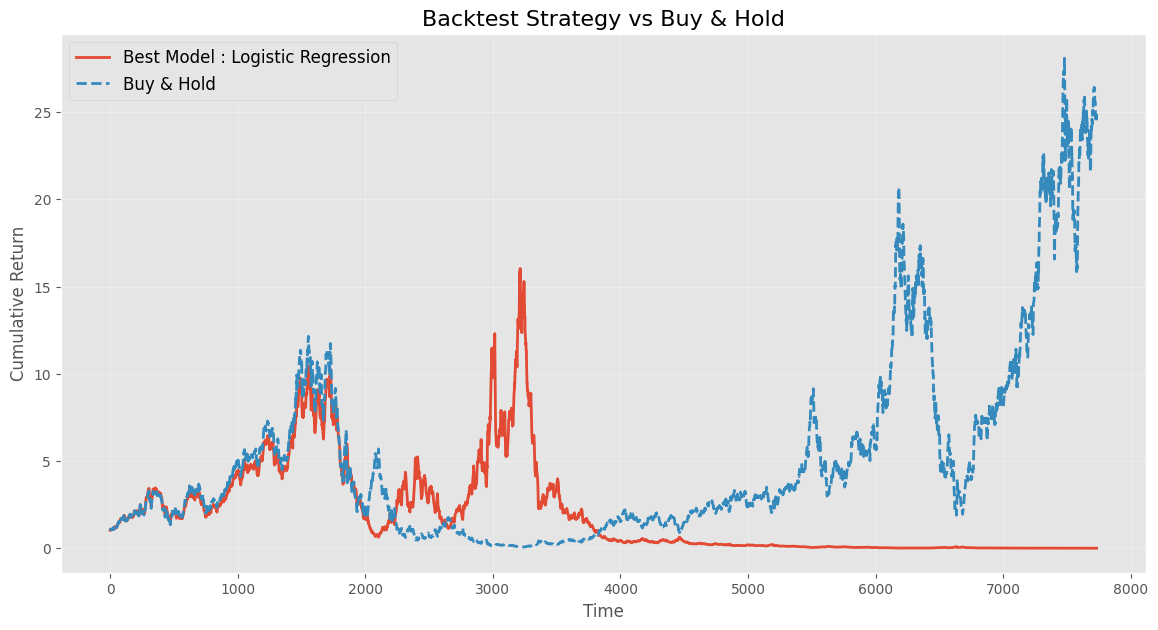

In [62]:
import matplotlib.pyplot as plt

# Courbe cumulative
plt.figure(figsize=(14,7))

plt.plot(
    bt["strategy_equity"],
    linewidth=2,
    label="Best Model : Logistic Regression"
)

plt.plot(
    bt["market_equity"],
    linestyle="--",
    linewidth=2,
    label="Buy & Hold"
)

plt.title(
    "Backtest Strategy vs Buy & Hold",
    fontsize=16
)

plt.xlabel("Time", fontsize=12)
plt.ylabel("Cumulative Return", fontsize=12)

plt.legend(fontsize=12)

plt.grid(True, alpha=0.3)

plt.show()